# `epilink`: Integrating Evolutionary and Epidemiological Signals to Uncover Superspreading Dynamics

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scripts.utils import *
from pathlib import Path

set_seaborn_paper_context(font_scale=1.5)

In [2]:
figs_dir = Path("../figures")
tabs_dir = Path("../tables")
formats = ["png", "pdf"]

def read_table(path: str) -> pd.DataFrame:
    path = tabs_dir / f"{path}.parquet"
    return pd.read_parquet(path)

## Features of `epilink`

In [3]:
toit_df = read_table("characterise_epilink/characteristic_toit_grid")
toit_df = toit_df[toit_df["days"] <= 15]
tost_df = read_table("characterise_epilink/characteristic_tost_grid")
tost_df = tost_df[tost_df["days"].between(-10, 10)]
presymptomatic_fraction_df = read_table("characterise_epilink/characteristic_presymptomatic_fraction")
stage_df = read_table("characterise_epilink/characteristic_stage_samples")
clock_rates_df = read_table("characterise_epilink/characteristic_clock_rate_samples")
temporal_df = read_table("characterise_epilink/characteristic_temporal_linkage")
genetic_df = read_table("characterise_epilink/characteristic_genetic_linkage")
surface_df = read_table("characterise_epilink/characteristic_probability_surface")
surface_pivot = surface_df.pivot(index="days", columns="snp", values="probability")
scenarios_df = read_table("characterise_epilink/characteristic_genetic_scenarios")
scenario_pivot = scenarios_df.pivot(index="m", columns="snp", values="normalized")

In [4]:
presymptomatic_fraction = presymptomatic_fraction_df.iloc[0, 0]
K = stage_df.loc[stage_df["stage"] == "latent", "value"].to_numpy()
P = stage_df.loc[stage_df["stage"] == "presymptomatic", "value"].to_numpy()
I = stage_df.loc[stage_df["stage"] == "symptomatic", "value"].to_numpy()

KP = K + P
KPI = KP + I

disease_dynamic = pd.DataFrame({
    "Latent": K,
    "Presymptomatic": KP,
    "Symptomatic": KPI,
}).melt(var_name="Stage", value_name="Duration")
disease_dynamic = disease_dynamic[disease_dynamic["Duration"] <= 15]

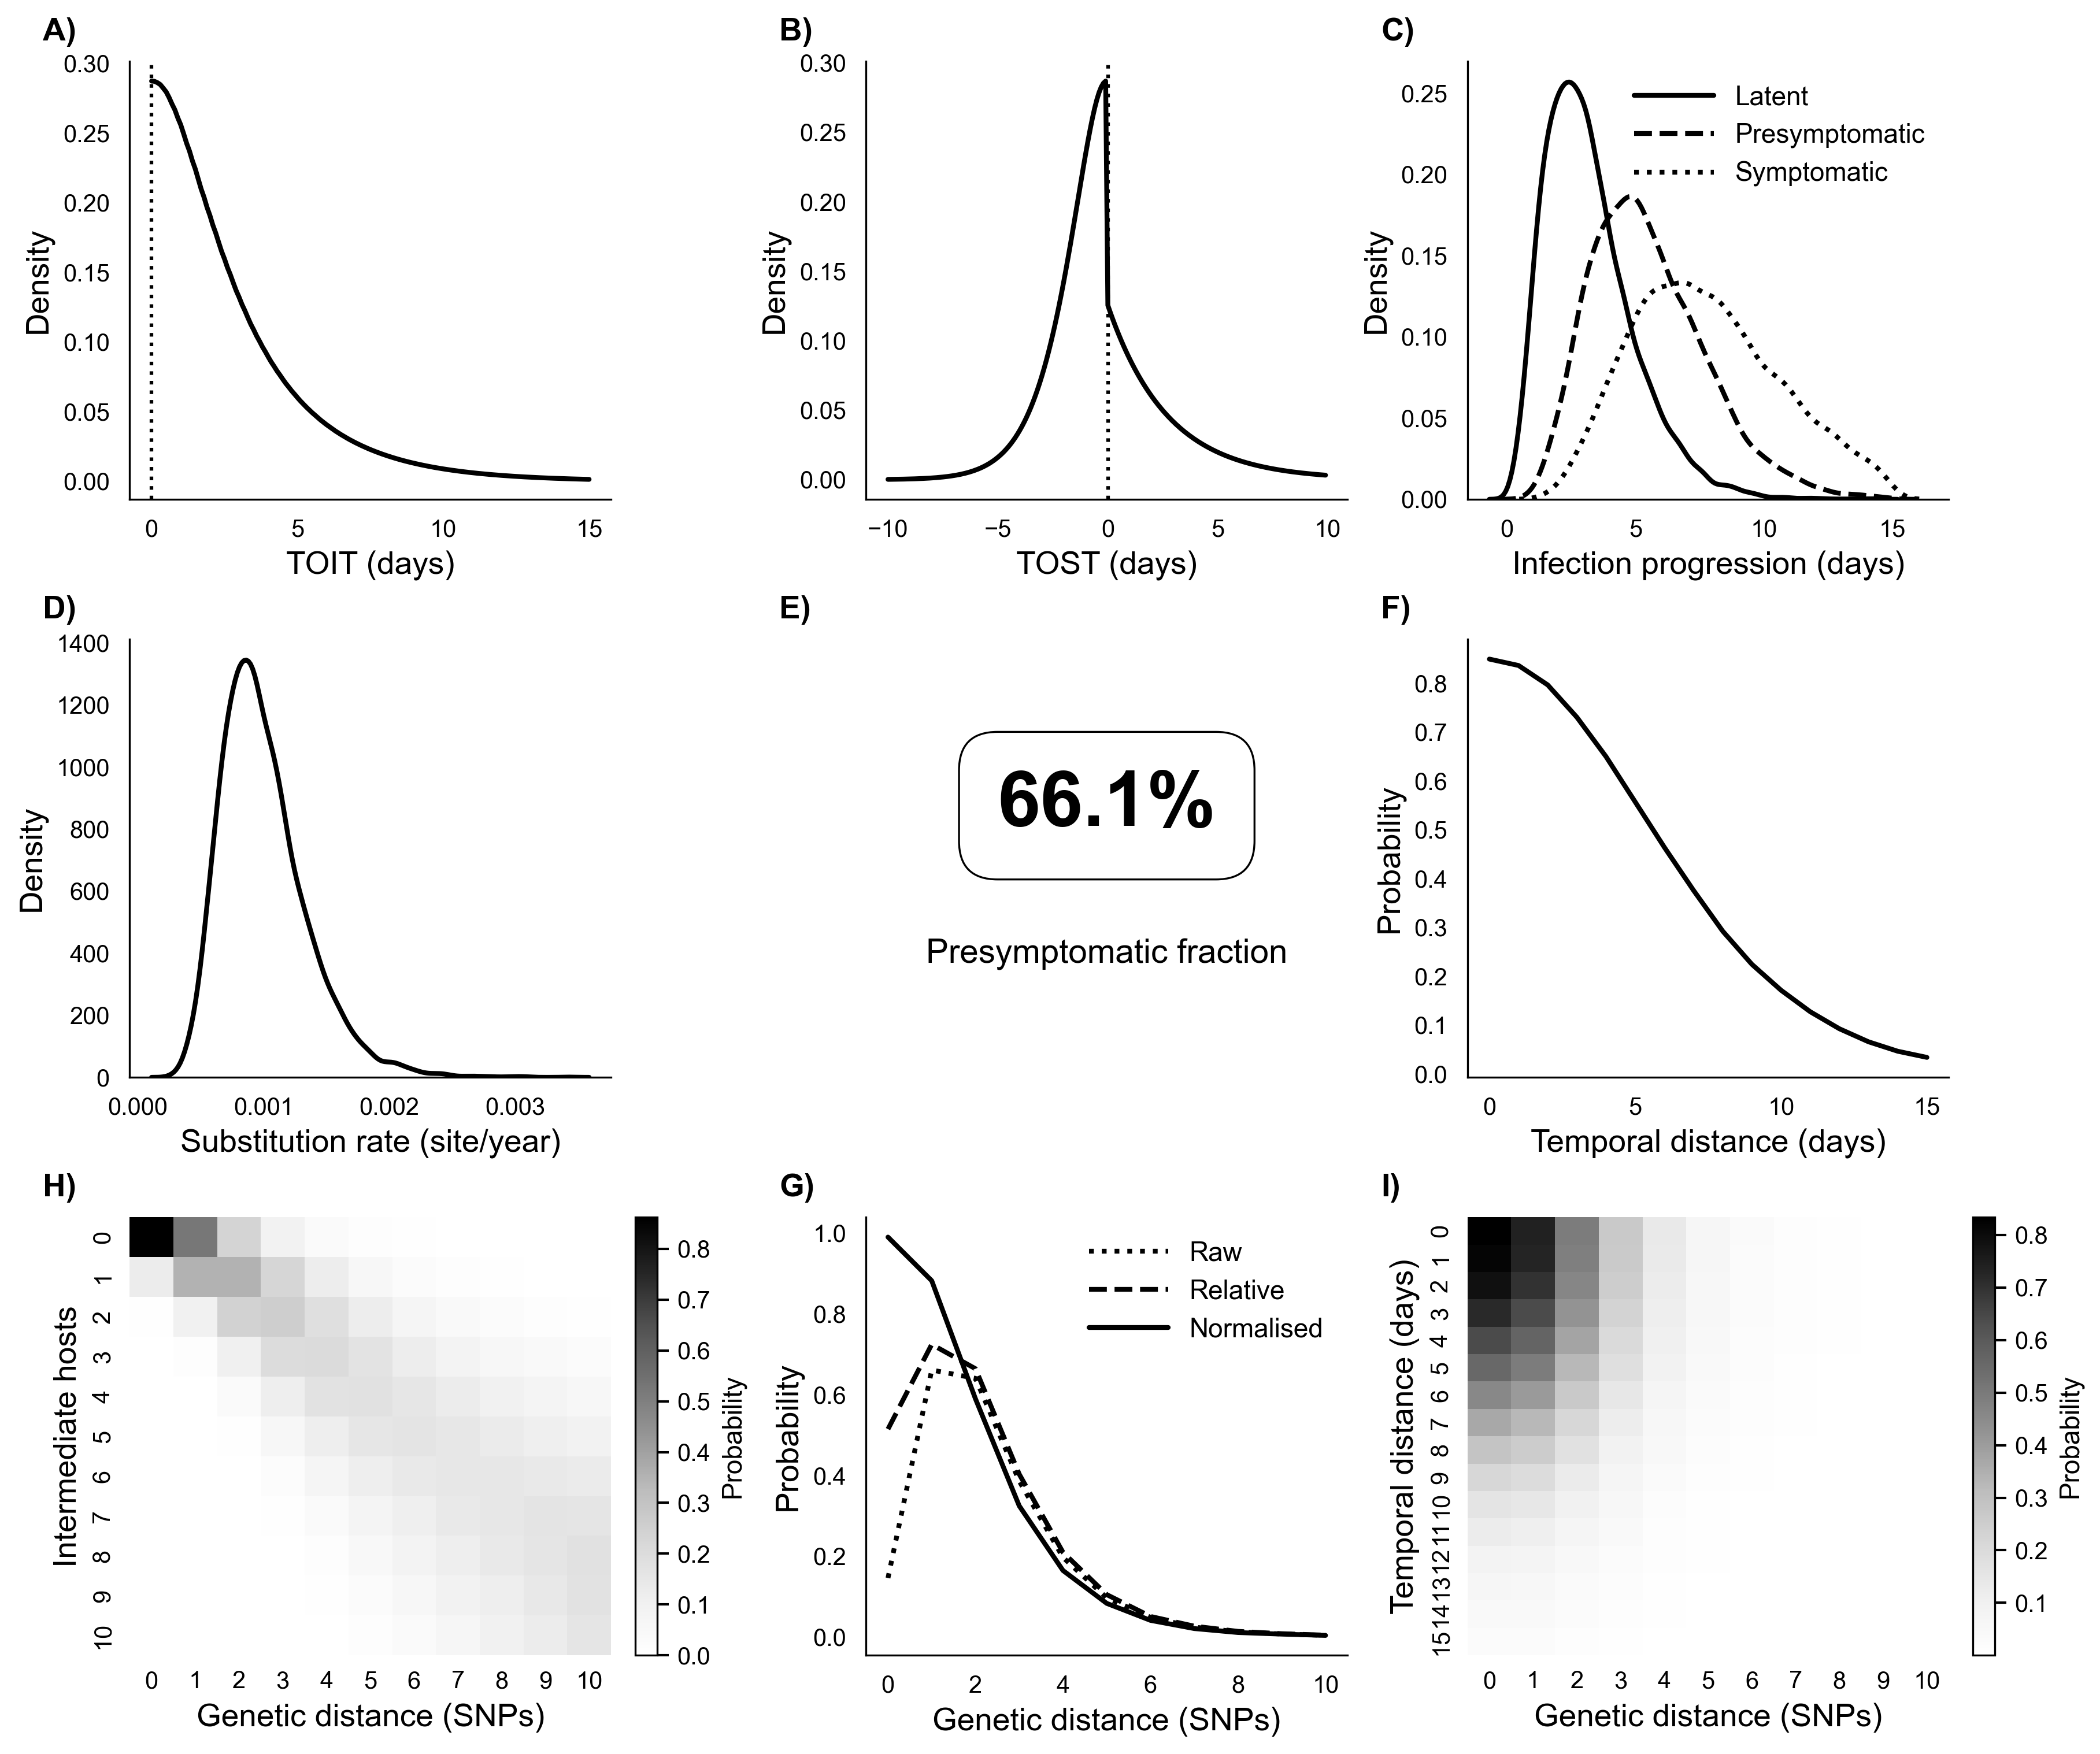

In [5]:
# -------------------------
# Figure + layout
# -------------------------
fig = plt.figure(figsize=(12, 10), constrained_layout=True)
gs = fig.add_gridspec(3, 3)

ax1 = fig.add_subplot(gs[0, 0])  # TOIT
ax2 = fig.add_subplot(gs[0, 1])  # TOST
ax3 = fig.add_subplot(gs[0, 2])  # Stage durations
ax4 = fig.add_subplot(gs[1, 0])  # Clock rate
ax5 = fig.add_subplot(gs[1, 1])  # Presymptomatic fraction
ax6 = fig.add_subplot(gs[1, 2])  # Temporal probability
ax7 = fig.add_subplot(gs[2, 1])  # Genetic curves
ax8 = fig.add_subplot(gs[2, 0])  # Scenario heatmap
ax9 = fig.add_subplot(gs[2, 2])  # Surface heatmap

font_size = "large"

# -------------------------
# A) TOIT
# -------------------------
sns.lineplot(data=toit_df, x="days", y="pdf", ax=ax1, color="black", lw=2)
ax1.axvline(0, color="black", linestyle=":", lw=1.5)
ax1.set_xlabel("TOIT (days)", fontsize=font_size)
ax1.set_ylabel("Density", fontsize=font_size)

# -------------------------
# B) TOST
# -------------------------
sns.lineplot(data=tost_df, x="days", y="pdf", ax=ax2, color="black", lw=2)
ax2.axvline(0, color="black", linestyle=":", lw=1.5)
ax2.set_xlabel("TOST (days)", fontsize=font_size)
ax2.set_ylabel("Density", fontsize=font_size)

# -------------------------
# C) Stage durations (lines + linestyles; no fill)
# -------------------------
# Stable ordering for reproducibility
stages = list(disease_dynamic["Stage"].dropna().unique())
linestyles = ["-", "--", ":", "-."]  # extend if you have >3 stages

for i, stage in enumerate(stages):
    sns.kdeplot(
        data=disease_dynamic[disease_dynamic["Stage"] == stage],
        x="Duration",
        ax=ax3,
        color="black",
        lw=2,
        linestyle=linestyles[i % len(linestyles)],
        fill=False,
        common_norm=False,
        label=str(stage),
    )

ax3.set_xlabel("Infection progression (days)", fontsize=font_size)
ax3.set_ylabel("Density", fontsize=font_size)

# Keep legend tidy
leg3 = ax3.legend(title=None, frameon=False, loc="best", handlelength=3,  fontsize="medium")
for line in leg3.get_lines():
    line.set_linewidth(2)

# -------------------------
# D) Clock rate distribution (no fill)
# -------------------------
sns.kdeplot(
    data=clock_rates_df,
    x="rate_per_site_year",
    ax=ax4,
    color="black",
    lw=2,
    fill=False
)
ax4.set_xlabel("Substitution rate (site/year)", fontsize=font_size)
ax4.set_ylabel("Density", fontsize=font_size)

# -------------------------
# E) Presymptomatic fraction “card”
# -------------------------
ax5.axis("off")
bbox = dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black", linewidth=0.8)

ax5.text(
    0.5, 0.62, f"{presymptomatic_fraction:.1%}",
    ha="center", va="center",
    fontsize=32, weight="bold", color="black",
    bbox=bbox
)
ax5.text(
    0.5, 0.28, "Presymptomatic fraction",
    ha="center", va="center",
    fontsize=14, color="black"
)

# -------------------------
# F) Temporal component
# -------------------------
sns.lineplot(
    data=temporal_df,
    x="days",
    y="probability",
    ax=ax6,
    color="black",
    lw=2
)
ax6.set_xlabel("Temporal distance (days)", fontsize=font_size)
ax6.set_ylabel("Probability", fontsize=font_size)

# -------------------------
# G) Genetic component (linestyles distinguish curves)
# -------------------------
sns.lineplot(data=genetic_df, x="snp", y="raw",
             ax=ax7, color="black", lw=2, linestyle=":", label="Raw")
sns.lineplot(data=genetic_df, x="snp", y="relative",
             ax=ax7, color="black", lw=2, linestyle="--", label="Relative")
sns.lineplot(data=genetic_df, x="snp", y="normalized",
             ax=ax7, color="black", lw=2, linestyle="-", label="Normalised")

ax7.set_xlabel("Genetic distance (SNPs)", fontsize=font_size)
ax7.set_ylabel("Probability", fontsize=font_size)

leg7 = ax7.legend(frameon=False, loc="best", handlelength=3,  fontsize="medium")
for line in leg7.get_lines():
    line.set_linewidth(2)

# -------------------------
# H) Scenario heatmap (Greys)
# -------------------------
hm8 = sns.heatmap(
    scenario_pivot,
    cmap="Greys",
    ax=ax8,
    cbar_kws={"label": "Probability"},
    linewidths=0.0
)
ax8.set_xlabel("Genetic distance (SNPs)", fontsize=font_size)
ax8.set_ylabel("Intermediate hosts", fontsize=font_size)
ax8.tick_params(direction="out", length=3, width=0.8)

cbar8 = hm8.collections[0].colorbar
cbar8.outline.set_edgecolor("black")
cbar8.outline.set_linewidth(0.8)
cbar8.ax.yaxis.label.set_size("medium")

# -------------------------
# H) Surface heatmap (Greys)
# -------------------------
hm9 = sns.heatmap(
    surface_pivot,
    cmap="Greys",
    ax=ax9,
    cbar_kws={"label": "Probability"},
    linewidths=0.0
)
ax9.set_xlabel("Genetic distance (SNPs)", fontsize=font_size)
ax9.set_ylabel("Temporal distance (days)", fontsize=font_size)
ax9.tick_params(direction="out", length=3, width=0.8)

# Make colourbar a bit cleaner
cbar9 = hm9.collections[0].colorbar
cbar9.outline.set_edgecolor("black")
cbar9.outline.set_linewidth(0.8)
cbar9.ax.yaxis.label.set_size("medium")

# -------------------------
# Panel labels (A–I)
# -------------------------

panel_axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]
for ax, lab in zip(panel_axes, ["A", "B", "C", "D", "E", "F", "G", "H", "I"]):
    ax.text(
        -0.18, 1.10, f"{lab})",
        transform=ax.transAxes,
        fontsize=font_size, fontweight="bold",
        va="top"
    )

# -------------------------
# Save + show
# -------------------------
save_figure(fig, figs_dir / "epilink_feature_summary", formats)
plt.show()

## Characteristics of Transmission Tree

In [6]:
import networkx as nx
import json

def read_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Missing JSON: {path}")
    return json.loads(path.read_text(encoding="utf-8"))

def ccdf(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    arr = np.asarray(values, dtype=int)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.array([]), np.array([])
    arr = np.sort(arr)
    unique, first_idx = np.unique(arr, return_index=True)
    ccdf_vals = (arr.size - first_idx) / arr.size
    return unique, ccdf_vals

def tree_depths(g: nx.DiGraph) -> np.ndarray:
    roots = [n for n, d in g.in_degree(g.nodes) if d == 0]
    if not roots:
        raise ValueError("Tree has no roots (in-degree 0).")
    depths: dict[object, int] = {}
    for root in roots:
        for node, dist in nx.single_source_shortest_path_length(g, root).items():
            if node not in depths or dist < depths[node]:
                depths[node] = dist
    return np.asarray(list(depths.values()), dtype=int)


tree = nx.read_gml(
    "../data/processed/synthetic/scovmod/scovmod_tree.gml"
)
tree_out_deg = np.array([d for _, d in tree.out_degree(tree.nodes)], dtype=int)
tree_depth = tree_depths(tree)

heterogeneity = read_json(Path(
    "../data/processed/synthetic/scovmod/scovmod_tree_tree_heterogeneity.json"
))

tree_summary_df = read_table("scovmod/scovmod_tree_summary")
tree_degree_df = read_table("scovmod/scovmod_tree_degree_distributions")
tree_component_df = read_table("scovmod/scovmod_tree_component_sizes")

In [7]:
tree_summary_final = tree_summary_df.loc[tree_summary_df["label"] == "final_tree"]
tree_summary_final = tree_summary_final.iloc[0]

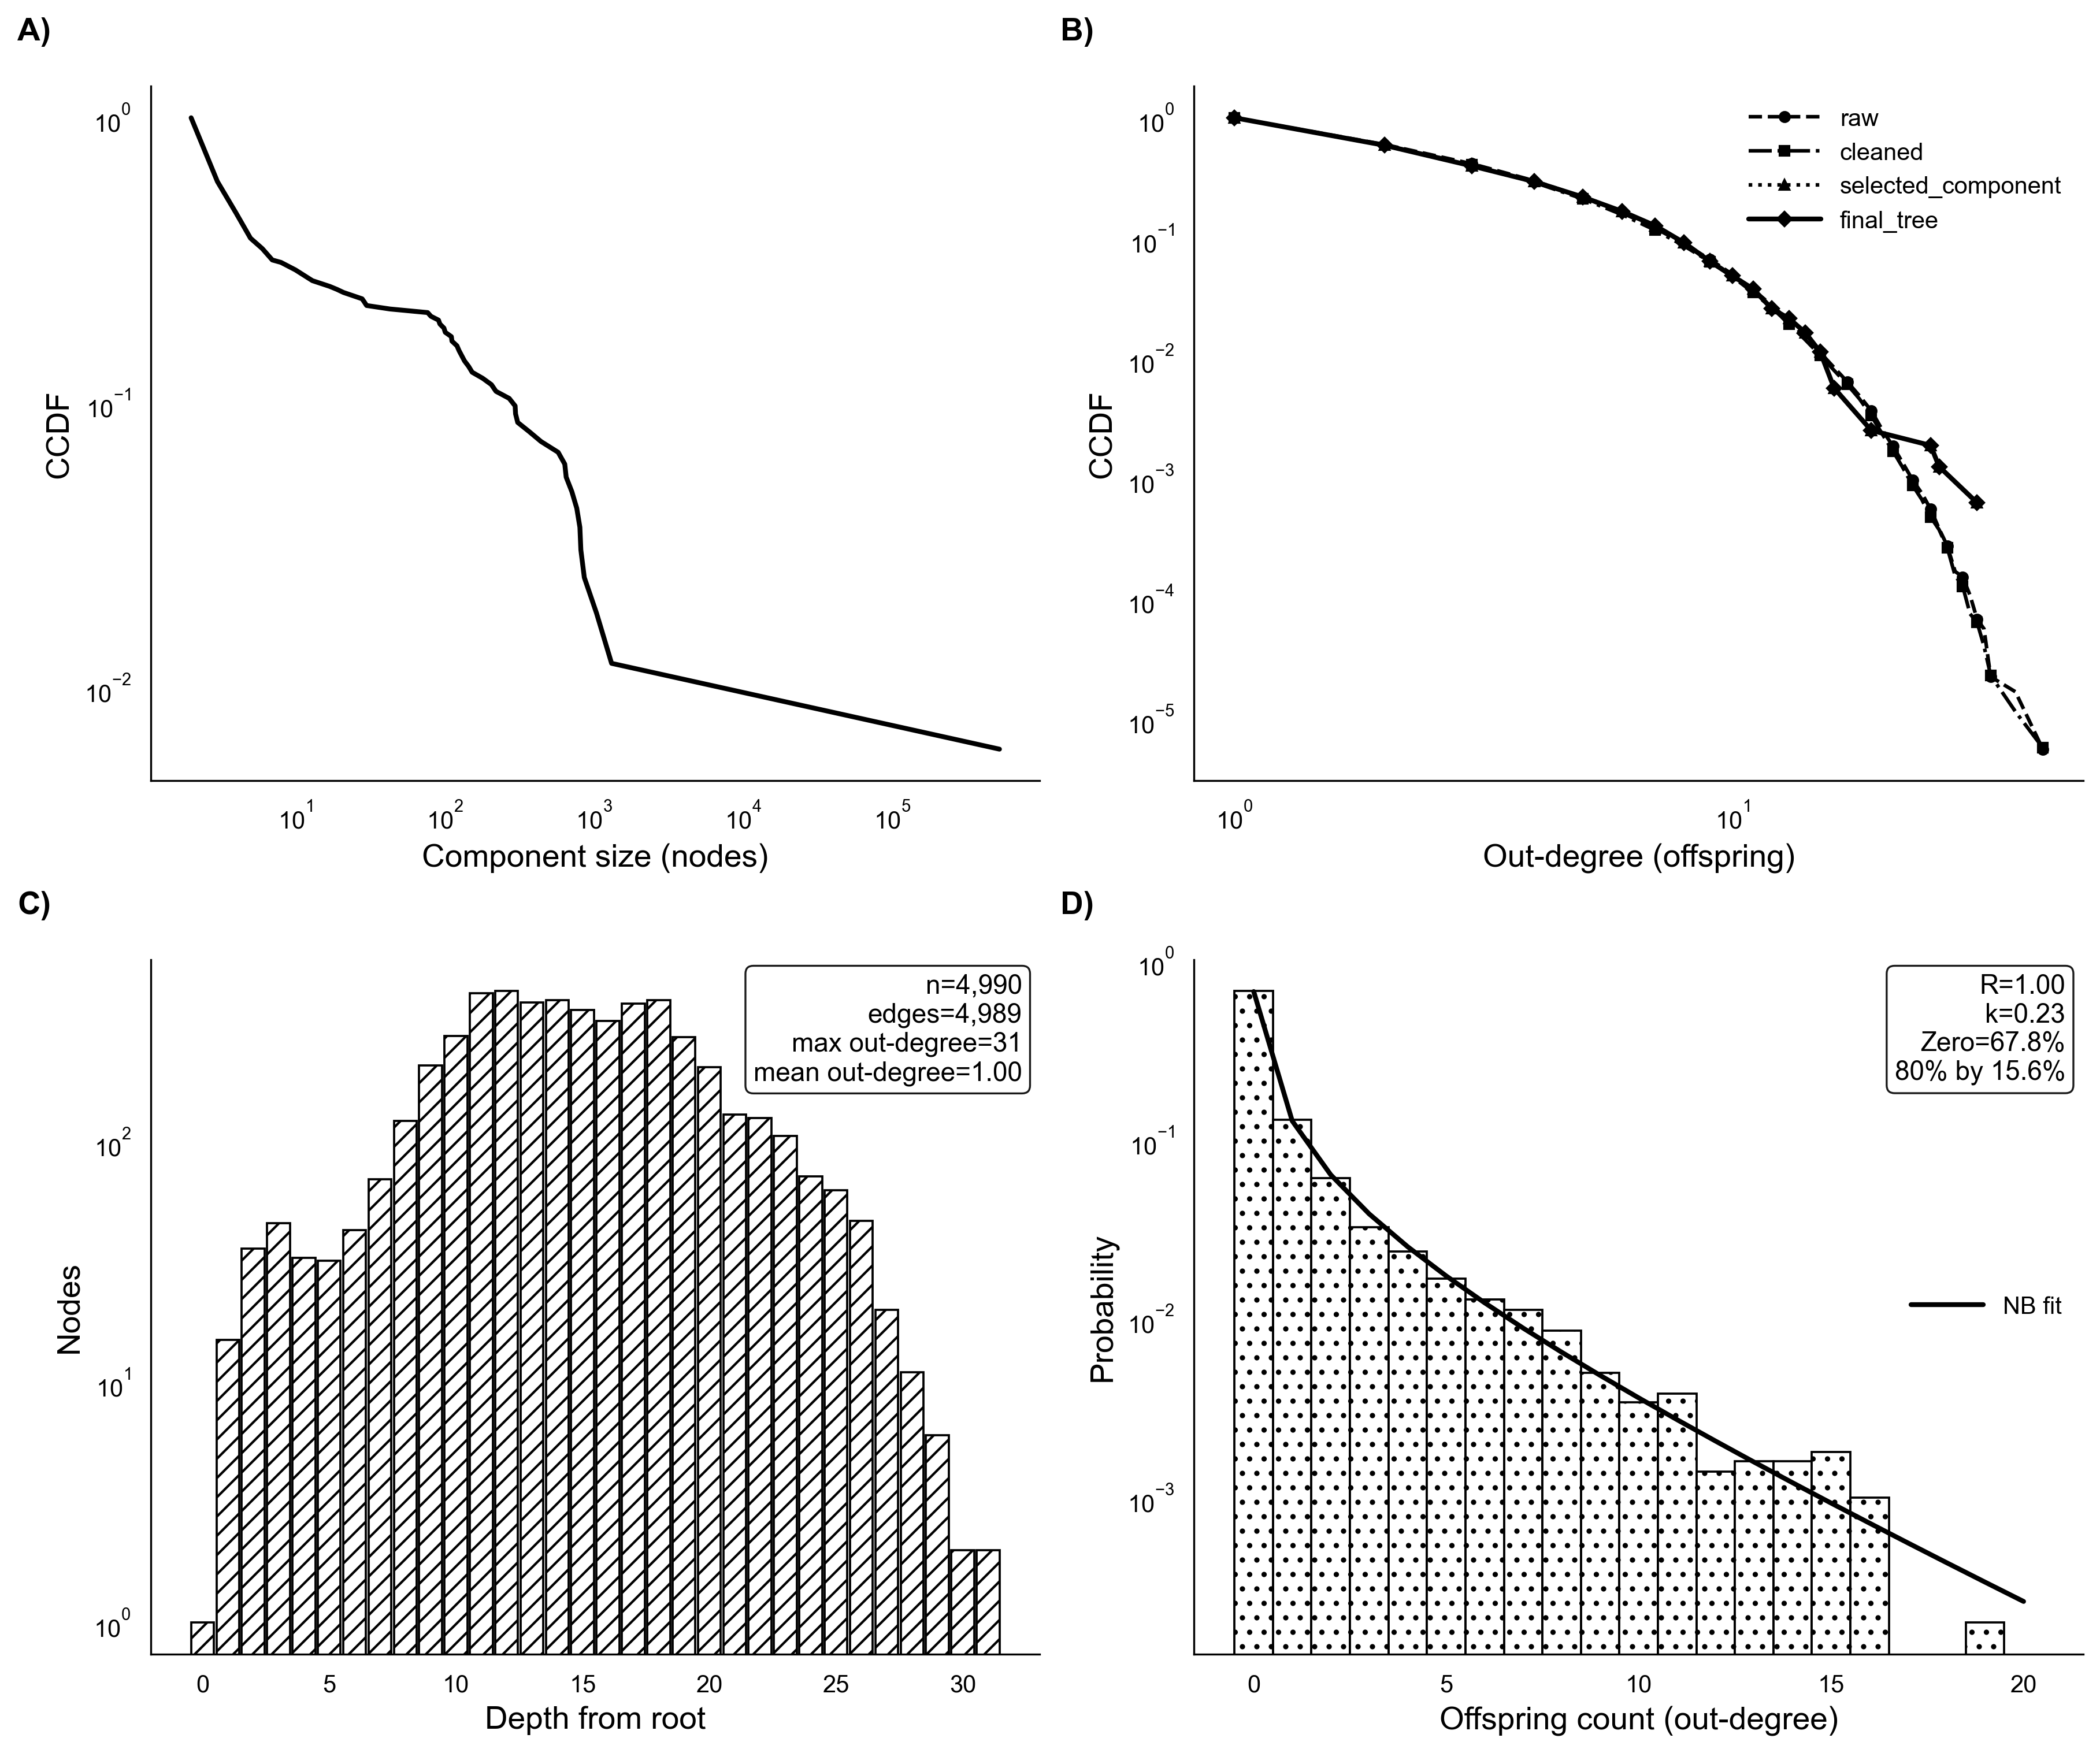

In [8]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
line_style_map = {
    "raw": ("--", "o"),
    "cleaned": ("-.", "s"),
    "selected_component": (":", "^"),
    "final_tree": ("-", "D"),
}

# A) Component size distribution (raw)
comp_sizes = tree_component_df["component_size"].to_numpy(dtype=int)
x_comp, y_comp = ccdf(comp_sizes)

axes[0, 0].plot(
    x_comp, y_comp,
    color="black", lw=2, linestyle="-"
)
axes[0, 0].set_xscale("log")
axes[0, 0].set_yscale("log")
axes[0, 0].set_xlabel("Component size (nodes)", fontsize=font_size)
axes[0, 0].set_ylabel("CCDF", fontsize=font_size)

# B) Out-degree CCDF across construction steps
for label in ["raw", "cleaned", "selected_component"]:
    subset = tree_degree_df.loc[
        (tree_degree_df["graph"] == label) & (tree_degree_df["degree_type"] == "out"),
        "value"
    ]
    vals = subset.to_numpy(dtype=int)
    vals = vals[vals > 0]
    if vals.size == 0:
        continue

    x, y = ccdf(vals)
    ls, mk = line_style_map[label]
    axes[0, 1].plot(
        x, y,
        color="black", lw=1.5,
        linestyle=ls,
        marker=mk, markersize=4,
        markevery=max(1, len(x)//12),
        label=label
    )

tree_nonzero = tree_out_deg[tree_out_deg > 0]
if tree_nonzero.size > 0:
    x_tree, y_tree = ccdf(tree_nonzero)
    ls, mk = line_style_map["final_tree"]
    axes[0, 1].plot(
        x_tree, y_tree,
        color="black", lw=2,
        linestyle=ls,
        marker=mk, markersize=4,
        markevery=max(1, len(x_tree)//12),
        label="final_tree"
    )

axes[0, 1].set_xscale("log")
axes[0, 1].set_yscale("log")
axes[0, 1].set_xlabel("Out-degree (offspring)", fontsize=font_size)
axes[0, 1].set_ylabel("CCDF", fontsize=font_size)
axes[0, 1].legend(frameon=False, title=None, handlelength=3)

# C) Depth distribution
depth_counts = pd.Series(tree_depth).value_counts().sort_index()

bars = axes[1, 0].bar(
    depth_counts.index,
    depth_counts.values,
    color="white",
    edgecolor="black",
    linewidth=0.9,
    width=0.9
)
for b in bars:
    b.set_hatch("///")

axes[1, 0].set_xlabel("Depth from root", fontsize=font_size)
axes[1, 0].set_ylabel("Nodes", fontsize=font_size)
axes[1, 0].set_yscale("log")

text = (
    f"n={int(tree_summary_final['n_nodes']):,}\n"
    f"edges={int(tree_summary_final['n_edges']):,}\n"
    f"max out-degree={int(tree_summary_final['max_out_degree'])}\n"
    f"mean out-degree={tree_summary_final['mean_out_degree']:.2f}"
)
axes[1, 0].text(
    0.98, 0.98, text,
    transform=axes[1, 0].transAxes,
    ha="right", va="top",
    fontsize="medium",
    bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "black", "alpha": 0.9},
)

# D) Offspring distribution with NB fit
x_max = int(np.quantile(tree_out_deg, 0.99))
x_max = max(20, min(x_max, int(tree_out_deg.max())))
bins = np.arange(-0.5, x_max + 1.5, 1.0)

sns.histplot(
    tree_out_deg,
    bins=bins,
    stat="probability",
    color="white",
    edgecolor="black",
    linewidth=0.9,
    ax=axes[1, 1],
)

# Add hatch to histogram patches
for p in axes[1, 1].patches:
    p.set_hatch("..")

mean_rt = float(heterogeneity.get("meanRt", np.nan))
disp_k = float(heterogeneity.get("disp_k", np.nan))

if np.isfinite(mean_rt) and np.isfinite(disp_k) and disp_k > 0:
    x_vals = np.arange(0, x_max + 1, dtype=int)
    p = disp_k / (disp_k + mean_rt)
    pmf = stats.nbinom.pmf(x_vals, disp_k, p)
    pmf = np.clip(pmf, 1e-12, None)
    axes[1, 1].plot(
        x_vals, pmf,
        color="black",
        lw=2,
        linestyle="-",
        label="NB fit"
    )
    axes[1, 1].legend(frameon=False, handlelength=3)

axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("Offspring count (out-degree)", fontsize=font_size)
axes[1, 1].set_ylabel("Probability", fontsize=font_size)

text = (
    f"R={mean_rt:.2f}\n"
    f"k={disp_k:.2f}\n"
    f"Zero={heterogeneity.get('pct_zero_transmitters', np.nan):.1f}%\n"
    f"80% by {heterogeneity.get('prop_80_percent_transmitters', np.nan) * 100:.1f}%"
)
axes[1, 1].text(
    0.98, 0.98, text,
    transform=axes[1, 1].transAxes,
    ha="right", va="top",
    fontsize="medium",
    bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "black", "alpha": 0.9},
)

# Panel labels A–D
panel_axes = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]
for ax, lab in zip(panel_axes, ["A)", "B)", "C)", "D)"]):
    ax.text(
        -0.15, 1.10, lab,
        transform=ax.transAxes,
        fontsize=font_size, fontweight="bold",
        va="top"
    )

save_figure(fig, figs_dir / "scovmod_tree_overview", formats)
plt.show()
plt.close(fig)

## Pairwise Discrimination and Cluster Recovery

In [9]:
MODELS = {
    # Deterministic Divergence Similarity Score
    "LinearDistScore": "DDS",
     # Stochastic Divergence Similarity Score
    "PoissonDistScore": "SDS",
    # Deterministic Divergence Model-Derived Probability
    "ProbLinearDist": "DDP",
    # Stochastic Divergence Model-Derived Probability
    "ProbPoissonDist": "SDP",
    # Deterministic Divergence Logit-Derived Probability
    # (trained on 10% of labelled data)
    "LogitLinearDist10": "DDL1",
    # Deterministic Divergence Logit-Derived Probability
    # (trained on 100% of labelled data)
    "LogitLinearDist100": "DDL2",
    # Stochastic Divergence Logit-Derived Probability
    # (trained on 10% of labelled data)
    "LogitPoissonDist10": "SDL1",
    # Stochastic Divergence Logit-Derived Probability
    # (trained on 100% of labelled data)
    "LogitPoissonDist100": "SDL2",
}

SCENARIOS = {
    "baseline": "Baseline",
    "surveillance_moderate": "Surveillance (moderate)",
    "surveillance_severe": "Surveillance (severe)",
    "low_clock_signal": "Low clock signal",
    "low_incubation_shape": "Low incubation shape",
    "low_incubation_scale": "Low incubation scale",
    "high_clock_signal": "High clock signal",
    "high_incubation_shape": "High incubation shape",
    "high_incubation_scale": "High incubation scale",
    "relaxed_clock": "Relaxed clock",
    "adversarial": "Adversarial",
}

In [10]:
discrimination = read_table("discrimination/discrimination_metrics")
clustering_metrics = read_table("clustering/clustering_metrics")
clustering_stability = read_table("clustering/clustering_stability")

In [11]:
discrimination["ModelLabel"] = discrimination["Model"].map(MODELS)
discrimination["ScenarioLabel"] = discrimination["Scenario"].map(SCENARIOS)

clustering_metrics["ModelLabel"] = clustering_metrics["Weight_Column"].map(MODELS)
clustering_metrics["ScenarioLabel"] = clustering_metrics["Scenario"].map(SCENARIOS)

clustering_stability["ModelLabel"] = clustering_stability["Weight_Column"].map(MODELS)
clustering_stability["ScenarioLabel"] = clustering_stability["Scenario"].map(SCENARIOS)

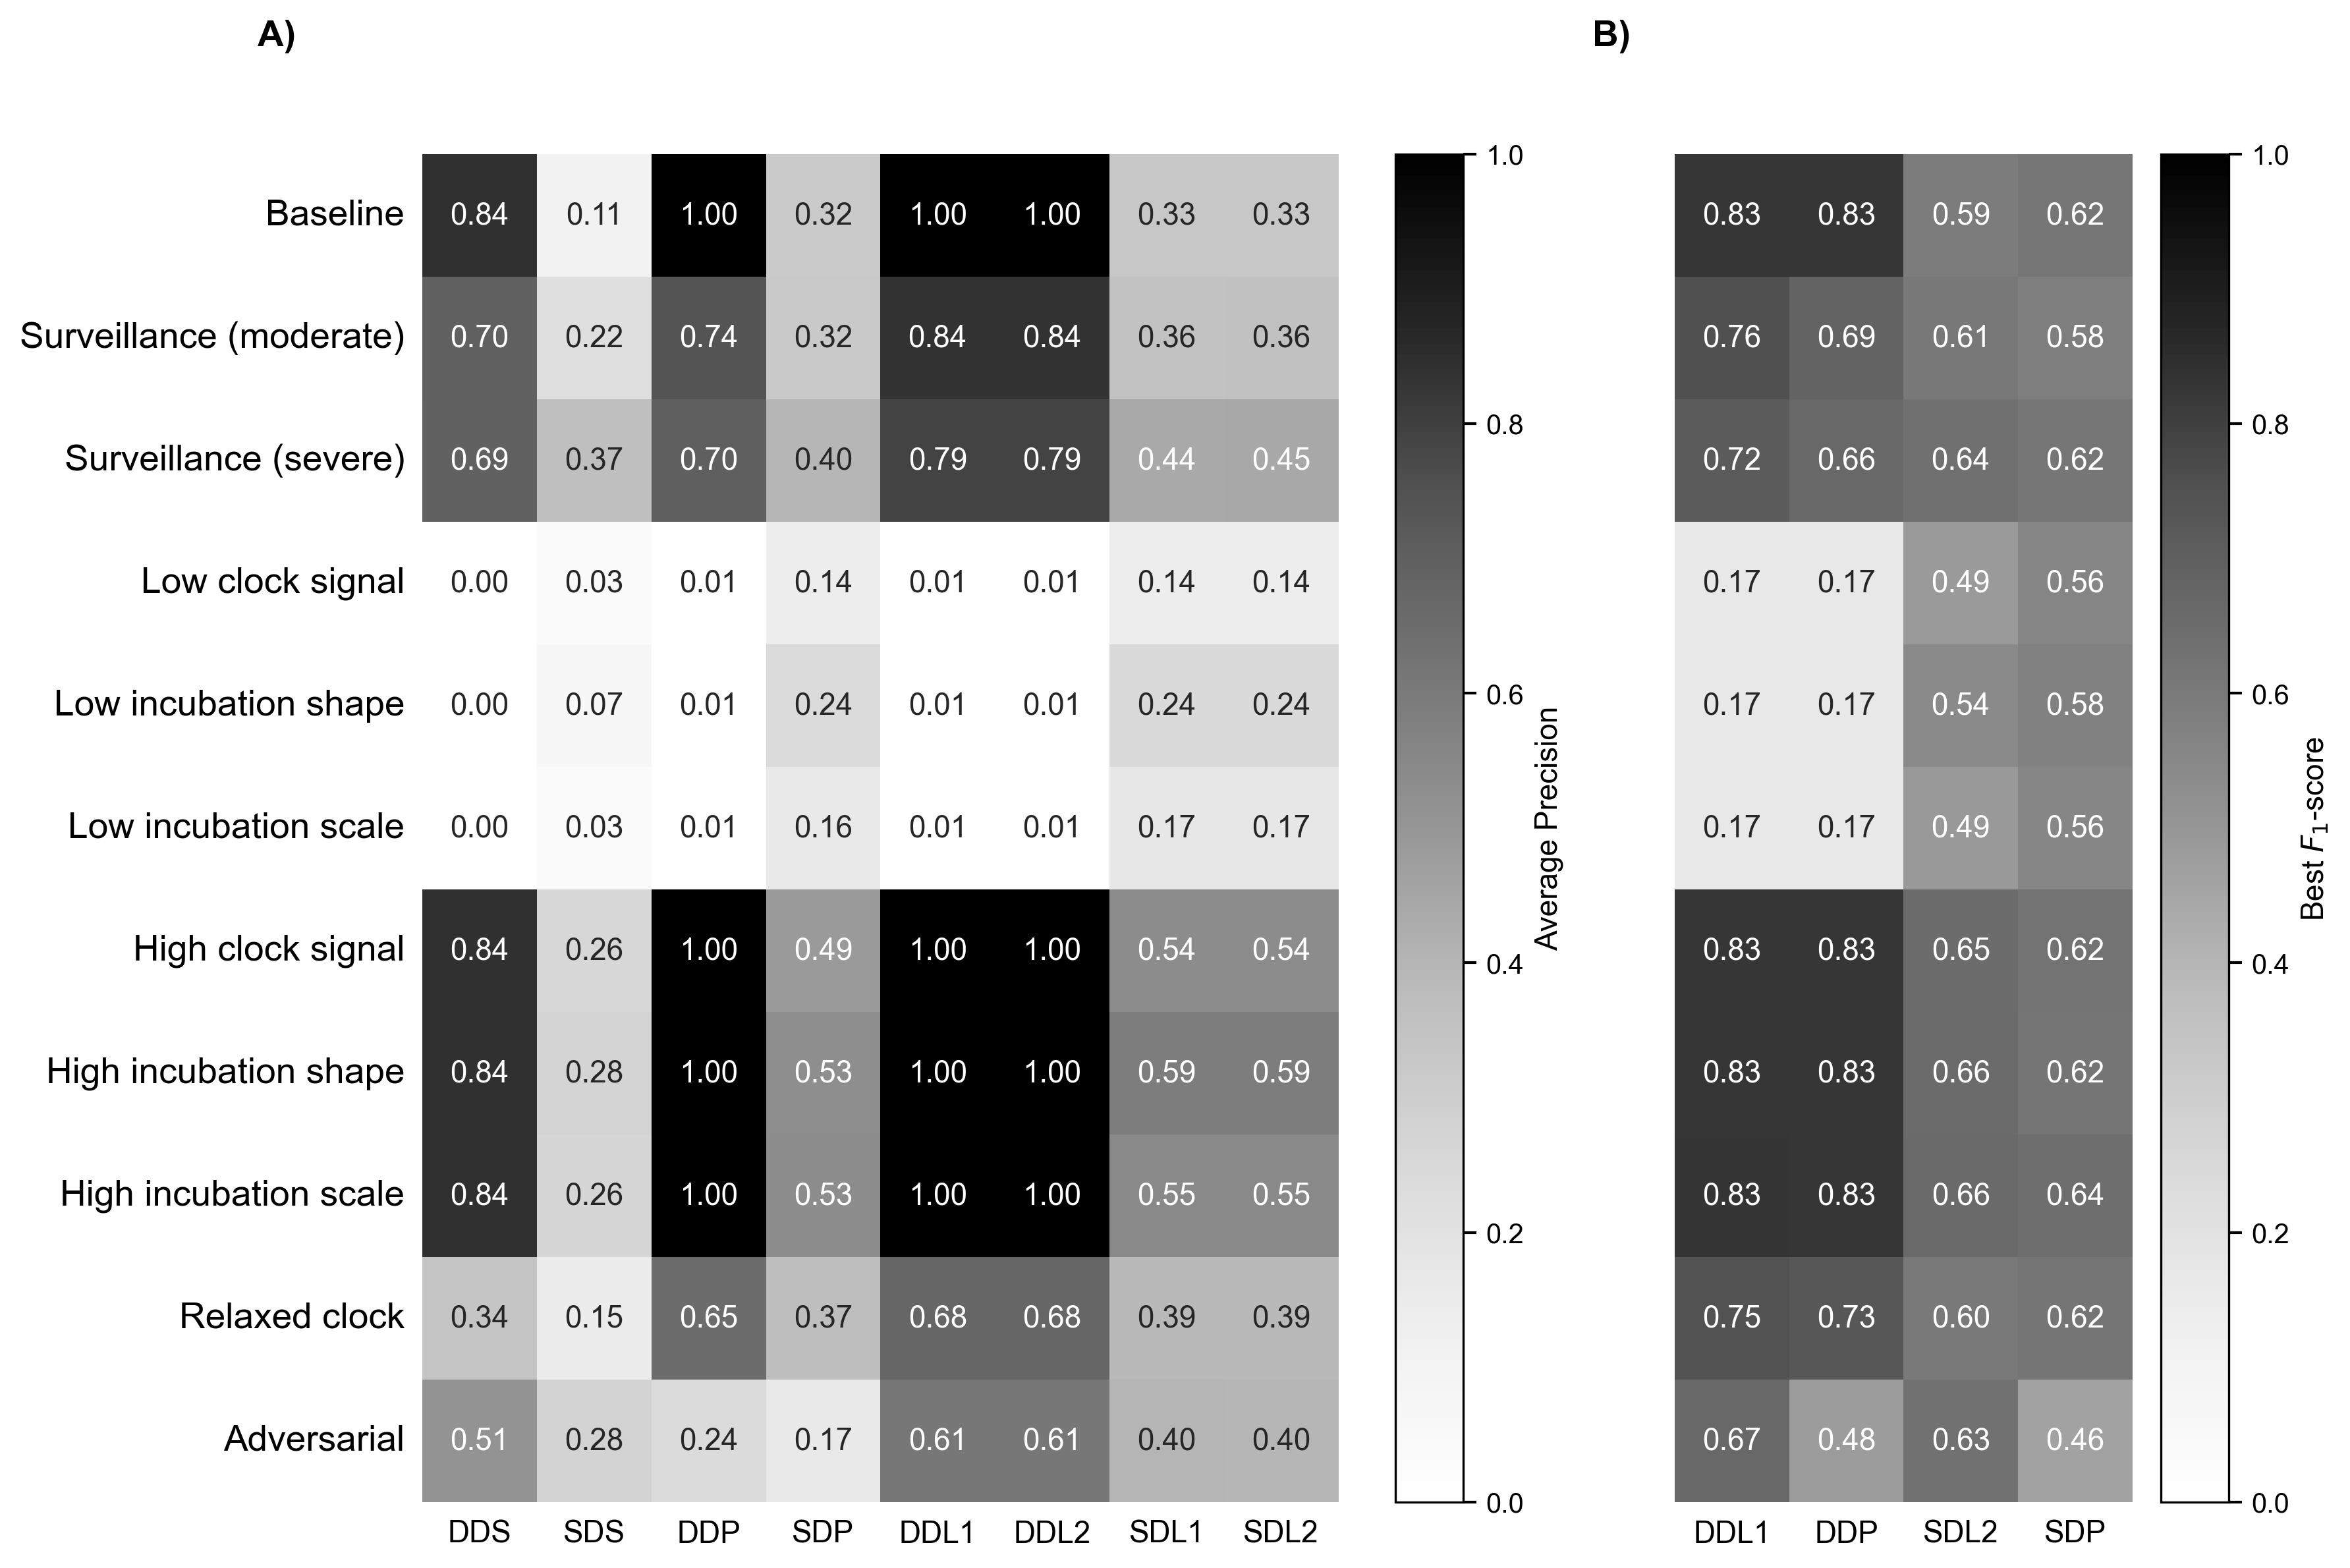

In [12]:
model_order = list(MODELS.values())
scenario_order = list(SCENARIOS.values())

pr_heat = discrimination.pivot(
    index="ScenarioLabel",
    columns="ModelLabel",
    values="PR_AUC",
).reindex(index=scenario_order, columns=model_order)

best_f1 = clustering_metrics.groupby(
    ["ScenarioLabel", "ModelLabel"], as_index=False
)["BCubed_F1_Score"].max()


best_f1_heat = best_f1.pivot(
    index="ScenarioLabel",
    columns="ModelLabel",
    values="BCubed_F1_Score",
).reindex(index=scenario_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharey=True,
                         width_ratios=[2, 1])
hm0 = sns.heatmap(
    pr_heat,
    vmin=0, vmax=1,
    cmap="Greys",
    annot=True, fmt=".2f",
    cbar_kws={"label": "Average Precision"},
    ax=axes[0]
)
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].tick_params(axis='y', labelsize="large")
axes[0].tick_params(axis='x', labelsize="medium")
axes[0].tick_params(direction="out", length=3, width=0.8)

cbar0 = hm0.collections[0].colorbar
cbar0.outline.set_edgecolor("black")
cbar0.outline.set_linewidth(0.8)
cbar0.ax.yaxis.label.set_size("medium")

hm1 = sns.heatmap(
    best_f1_heat,
    vmin=0, vmax=1,
    cmap="Greys",
    annot=True, fmt=".2f",
    cbar_kws={"label": r"Best $F_1$-score"},
    ax=axes[1]
)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', labelsize="medium")
axes[1].tick_params(direction="out", length=3, width=0.8)

cbar1 = hm1.collections[0].colorbar
cbar1.outline.set_edgecolor("black")
cbar1.outline.set_linewidth(0.8)
cbar1.ax.yaxis.label.set_size("medium")

panel_axes = [axes[0], axes[1]]
for ax, lab in zip(panel_axes, ["A", "B"]):
    ax.text(
        -0.18, 1.10, f"{lab})",
        transform=ax.transAxes,
        fontsize=font_size, fontweight="bold",
        va="top"
    )
plt.tight_layout()
save_figure(fig, figs_dir / "discrimination_recovery", formats)
plt.show()
plt.close(fig)

### Supplementary figures

In [13]:
import math
import string
def plot_cluster_metrics(
    df,
    out_path,
    metric="BCubed_F1_Score",
    y_axis="Resolution",
    ncols=3,
    figsize=(12, 12),
    show=False,
):
    m_order = ['DDP', 'DDL2', 'SDP', 'SDL2']
    line_styles = {'DDP': '-', 'DDL2': '--', 'SDP': ':', 'SDL2': '-.'}
    markers = {'DDP': 'o', 'DDL2': 's', 'SDP': '^', 'SDL2': 'D'}

    # Ensure scenario order is respected and stable
    scenarios = [s for s in scenario_order if s in set(df["ScenarioLabel"])]
    n_panels = len(scenarios)
    nrows = math.ceil(n_panels / ncols)

    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(nrows, ncols)

    axes = []
    for i in range(nrows * ncols):
        r, c = divmod(i, ncols)
        ax = fig.add_subplot(gs[r, c], sharey=axes[0] if axes else None)
        axes.append(ax)

    # ---- plotting ----
    # Collect legend handles from first axis only
    legend_handles, legend_labels = None, None

    for idx, scenario in enumerate(scenarios):
        ax = axes[idx]
        dsub = df[df["ScenarioLabel"] == scenario]

        # Plot each model as black line with unique style/marker
        for model in m_order:
            dmod = dsub[dsub["ModelLabel"] == model]
            if dmod.empty:
                continue

            ax.plot(
                dmod[y_axis],
                dmod[metric],
                color="black",
                linestyle=line_styles[model],
                marker=markers[model],
                linewidth=1.5,
                markersize=4,
                label=model
            )

        # panel title + clean axes
        ax.set_title(scenario, fontsize="large", pad=6, loc="left",)
        ax.set_ylim((0, 1.05))
        ax.tick_params(direction="out", length=3, width=0.8)

        # A), B), C)...
        panel_letter = string.ascii_uppercase[idx]
        ax.text(
            -0.18, 1.15, f"{panel_letter})",
            transform=ax.transAxes,
            fontsize="large",
            fontweight="bold",
            va="top",
        )

        # Store legend items once (from first plotted axis)
        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        # Only label left/bottom axes to reduce clutter
        if (idx % ncols) != 0:
            ax.set_ylabel("")
        if idx < (nrows - 1) * ncols:
            ax.set_xlabel("")

    # Turn off any unused axes (12th slot when 11 panels)
    for j in range(n_panels, nrows * ncols):
        axes[j].axis("off")

    # ---- common labels ----
    ylab = "-".join(metric.split("_")[1:])
    fig.supxlabel("\nResolution", fontsize="xx-large")
    fig.supylabel(f"\n\n{ylab}", fontsize="xx-large")

    # ---- shared legend ----
    if legend_handles:
        fig.legend(
            legend_handles,
            legend_labels,
            title="Genome Divergence and Probability Model",
            title_fontsize="large",
            fontsize="medium",
            loc="upper center",
            bbox_to_anchor=(0.5, 1.06),
            ncol=len(m_order),
            frameon=False,
            handlelength=3,
        )

    # ---- save ----
    fig.savefig(out_path.with_suffix(".png"), dpi=300, bbox_inches="tight")
    fig.savefig(out_path.with_suffix(".pdf"), bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

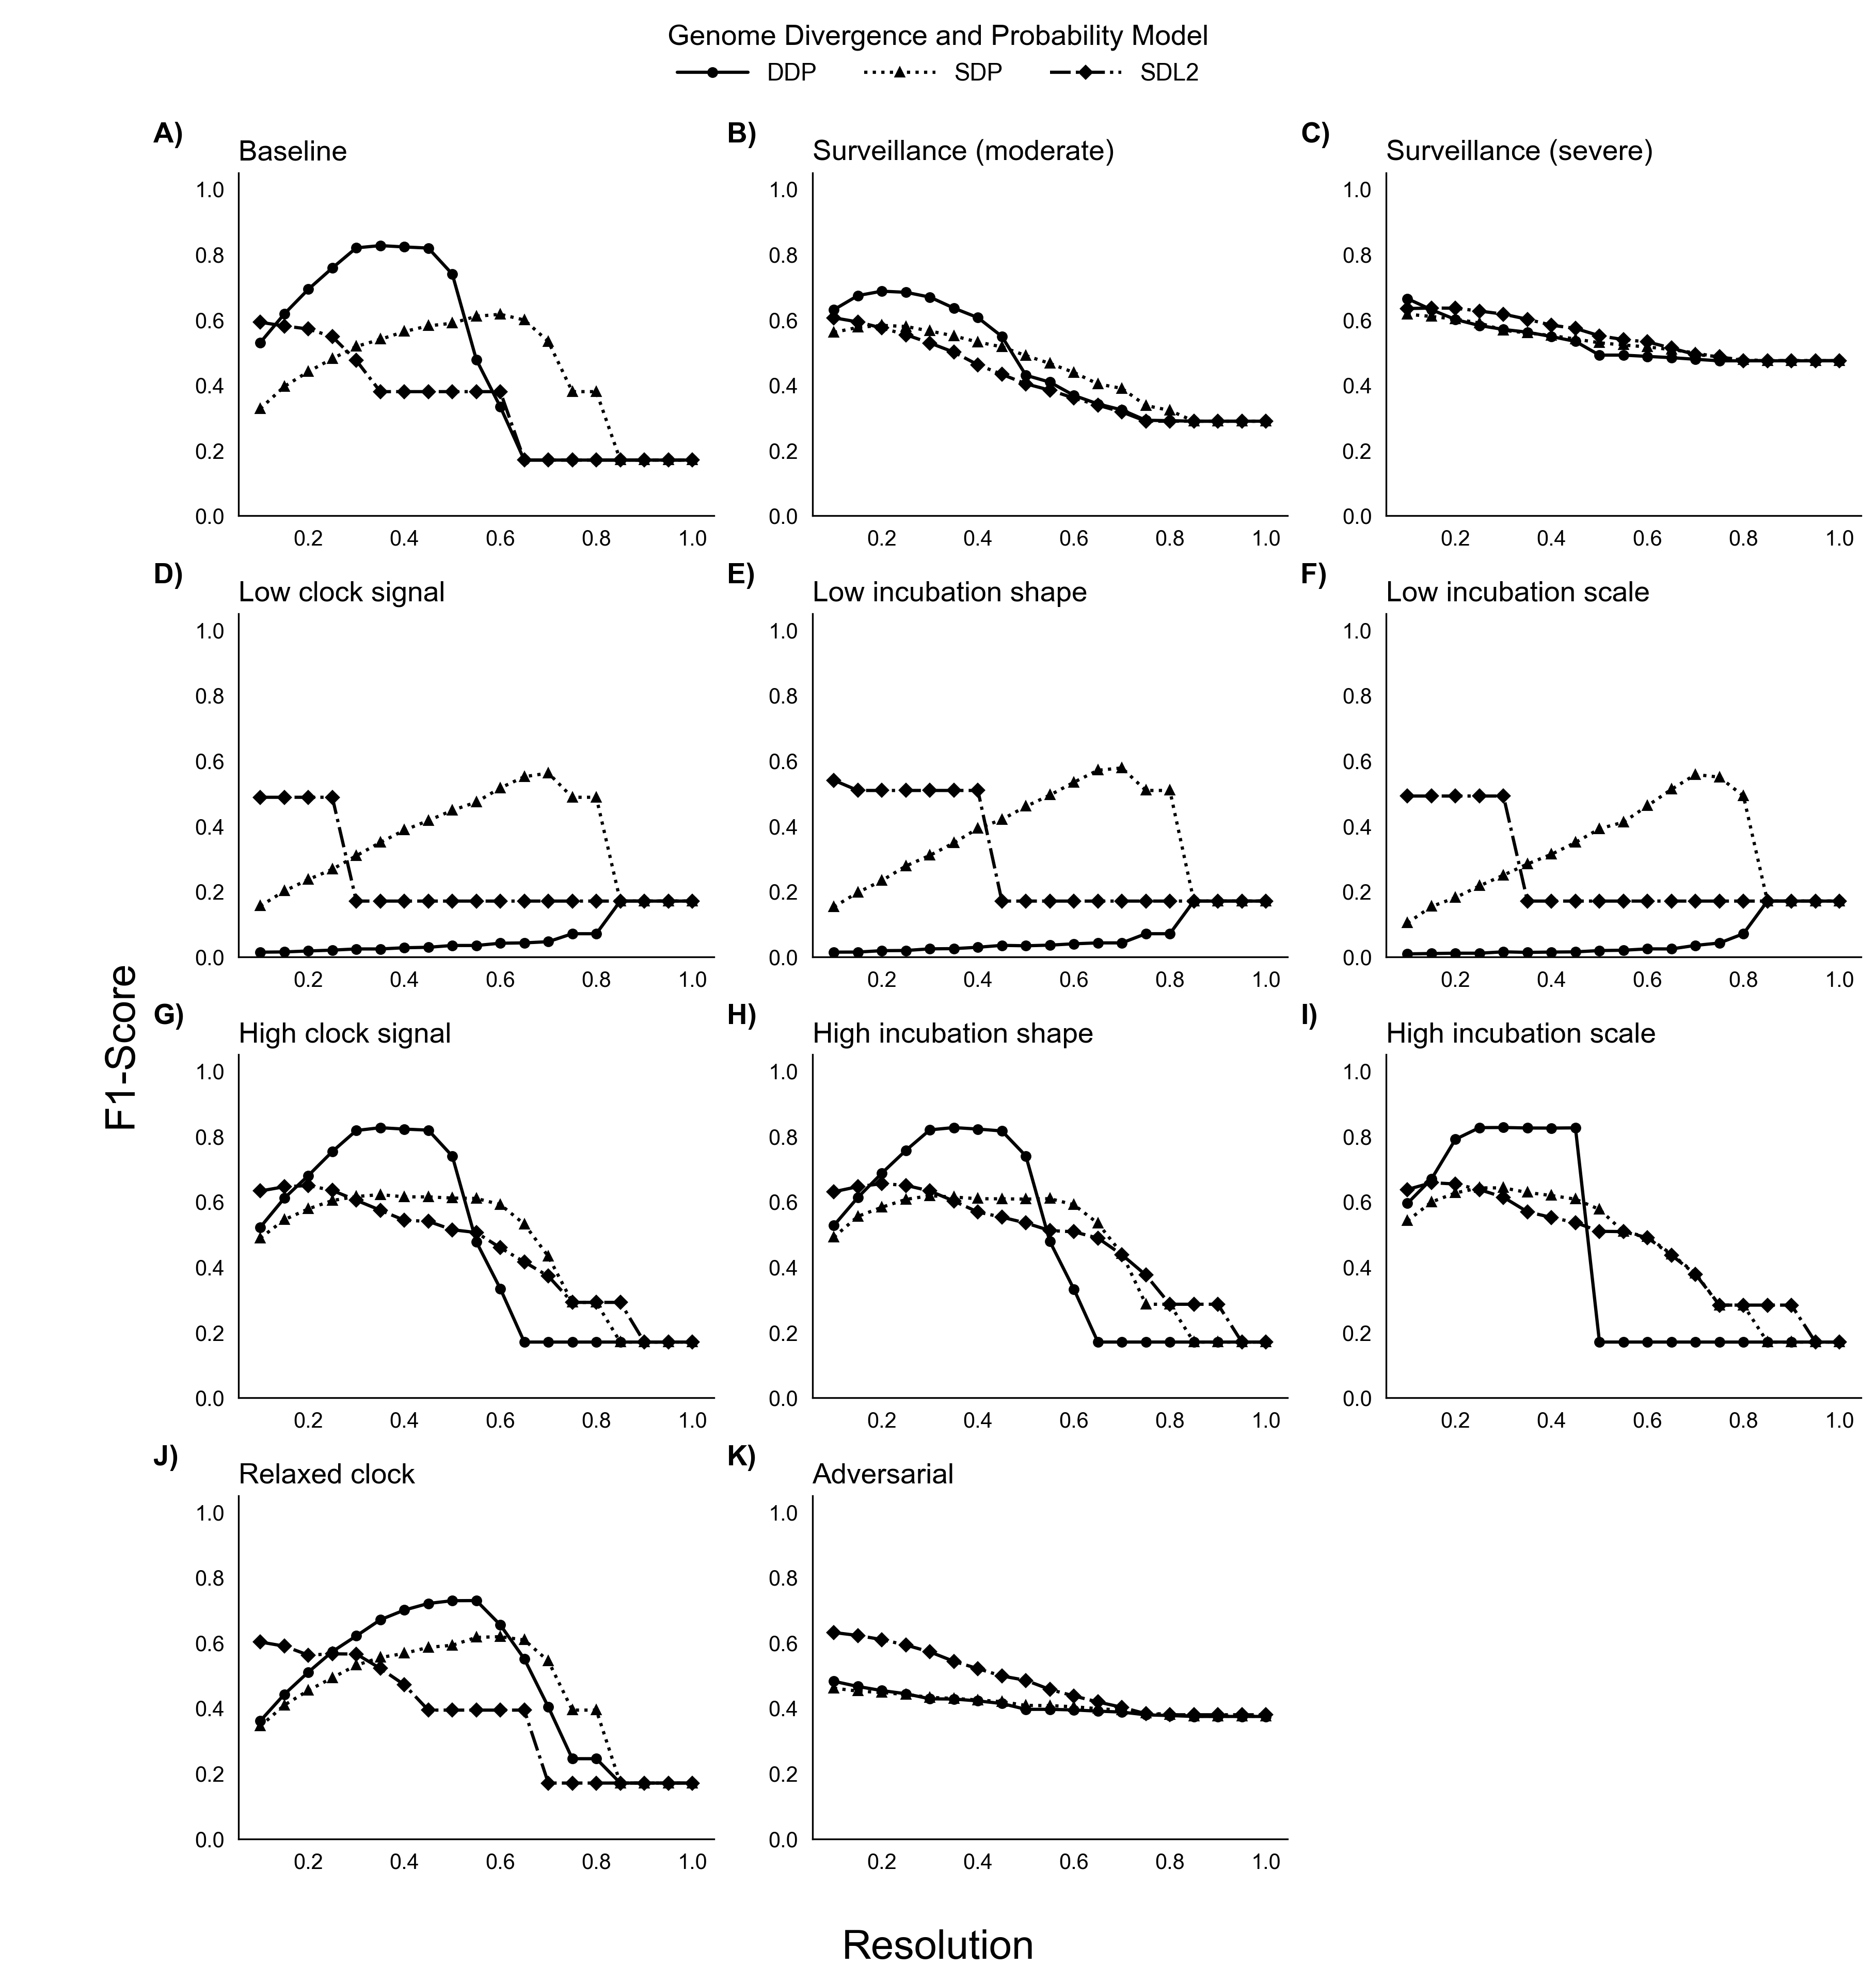

In [14]:
plot_cluster_metrics(
    clustering_metrics,
    out_path=figs_dir / "sm_cluster_metrics_f1",
    metric="BCubed_F1_Score",
    show=True,
)

In [15]:
plot_cluster_metrics(
    clustering_metrics,
    out_path=figs_dir / "sm_cluster_metrics_precision",
    metric="BCubed_Precision",
)

plot_cluster_metrics(
    clustering_metrics,
    out_path=figs_dir / "sm_cluster_metrics_recall",
    metric="BCubed_Recall",
)

plot_cluster_metrics(
    clustering_stability,
    out_path=figs_dir / "sm_clustering_stability_f1",
    metric="BCubed_F1_Score",
    y_axis="Res1",
)

## Temporal Stability of Clusters

In [16]:
from matplotlib.axes import Axes
def plot_stability_over_time(stability: pd.DataFrame, ax: Axes) -> Axes:
    line_styles = {'forward': '--', 'backward': ':', 'jaccard': '-'}
    markers = {'forward': 'o', 'backward': 's', 'jaccard': '^',}

    for m in line_styles.keys():
        ax.plot(stability.index, stability[m],
                linestyle=line_styles[m],
                linewidth=1.5,
                color="black",
                markersize=4,
                marker=markers[m],
                label=m.capitalize()
                )

    ax.set_xlabel("Epidemic week", fontsize="large")
    ax.set_ylabel("Mean stability", fontsize="large")
    ax.legend(loc="lower right", frameon=False, handlelength=3)
    ax.set_ylim(0, 1)
    return ax

def plot_cumulative_cases(counts: pd.DataFrame, ax: Axes) -> Axes:
    counts = counts.copy()
    counts["cumulative"] = counts["n_cases"].cumsum()

    bars = ax.bar(
    counts["available_time"],
    counts["cumulative"],
    color="white",
    edgecolor="black",
    linewidth=0.9,
    width=0.9
)
    for b in bars:
        b.set_hatch("..")

    ax.set_xlabel("Epidemic week", fontsize="large")
    ax.set_ylabel("Cumulative cases", fontsize="large")
    ax.set_yscale("log")
    return ax

In [17]:
data_accrual = read_table("temporal_stability/case_counts_over_time")
temporal_stability_ll = read_table("temporal_stability/temporal_stability_logit_linear")
temporal_stability_lp = read_table("temporal_stability/temporal_stability_logit_poisson")
temporal_stability_pl = read_table( "temporal_stability/temporal_stability_prob_linear")
temporal_stability_pp = read_table("temporal_stability/temporal_stability_prob_poisson")

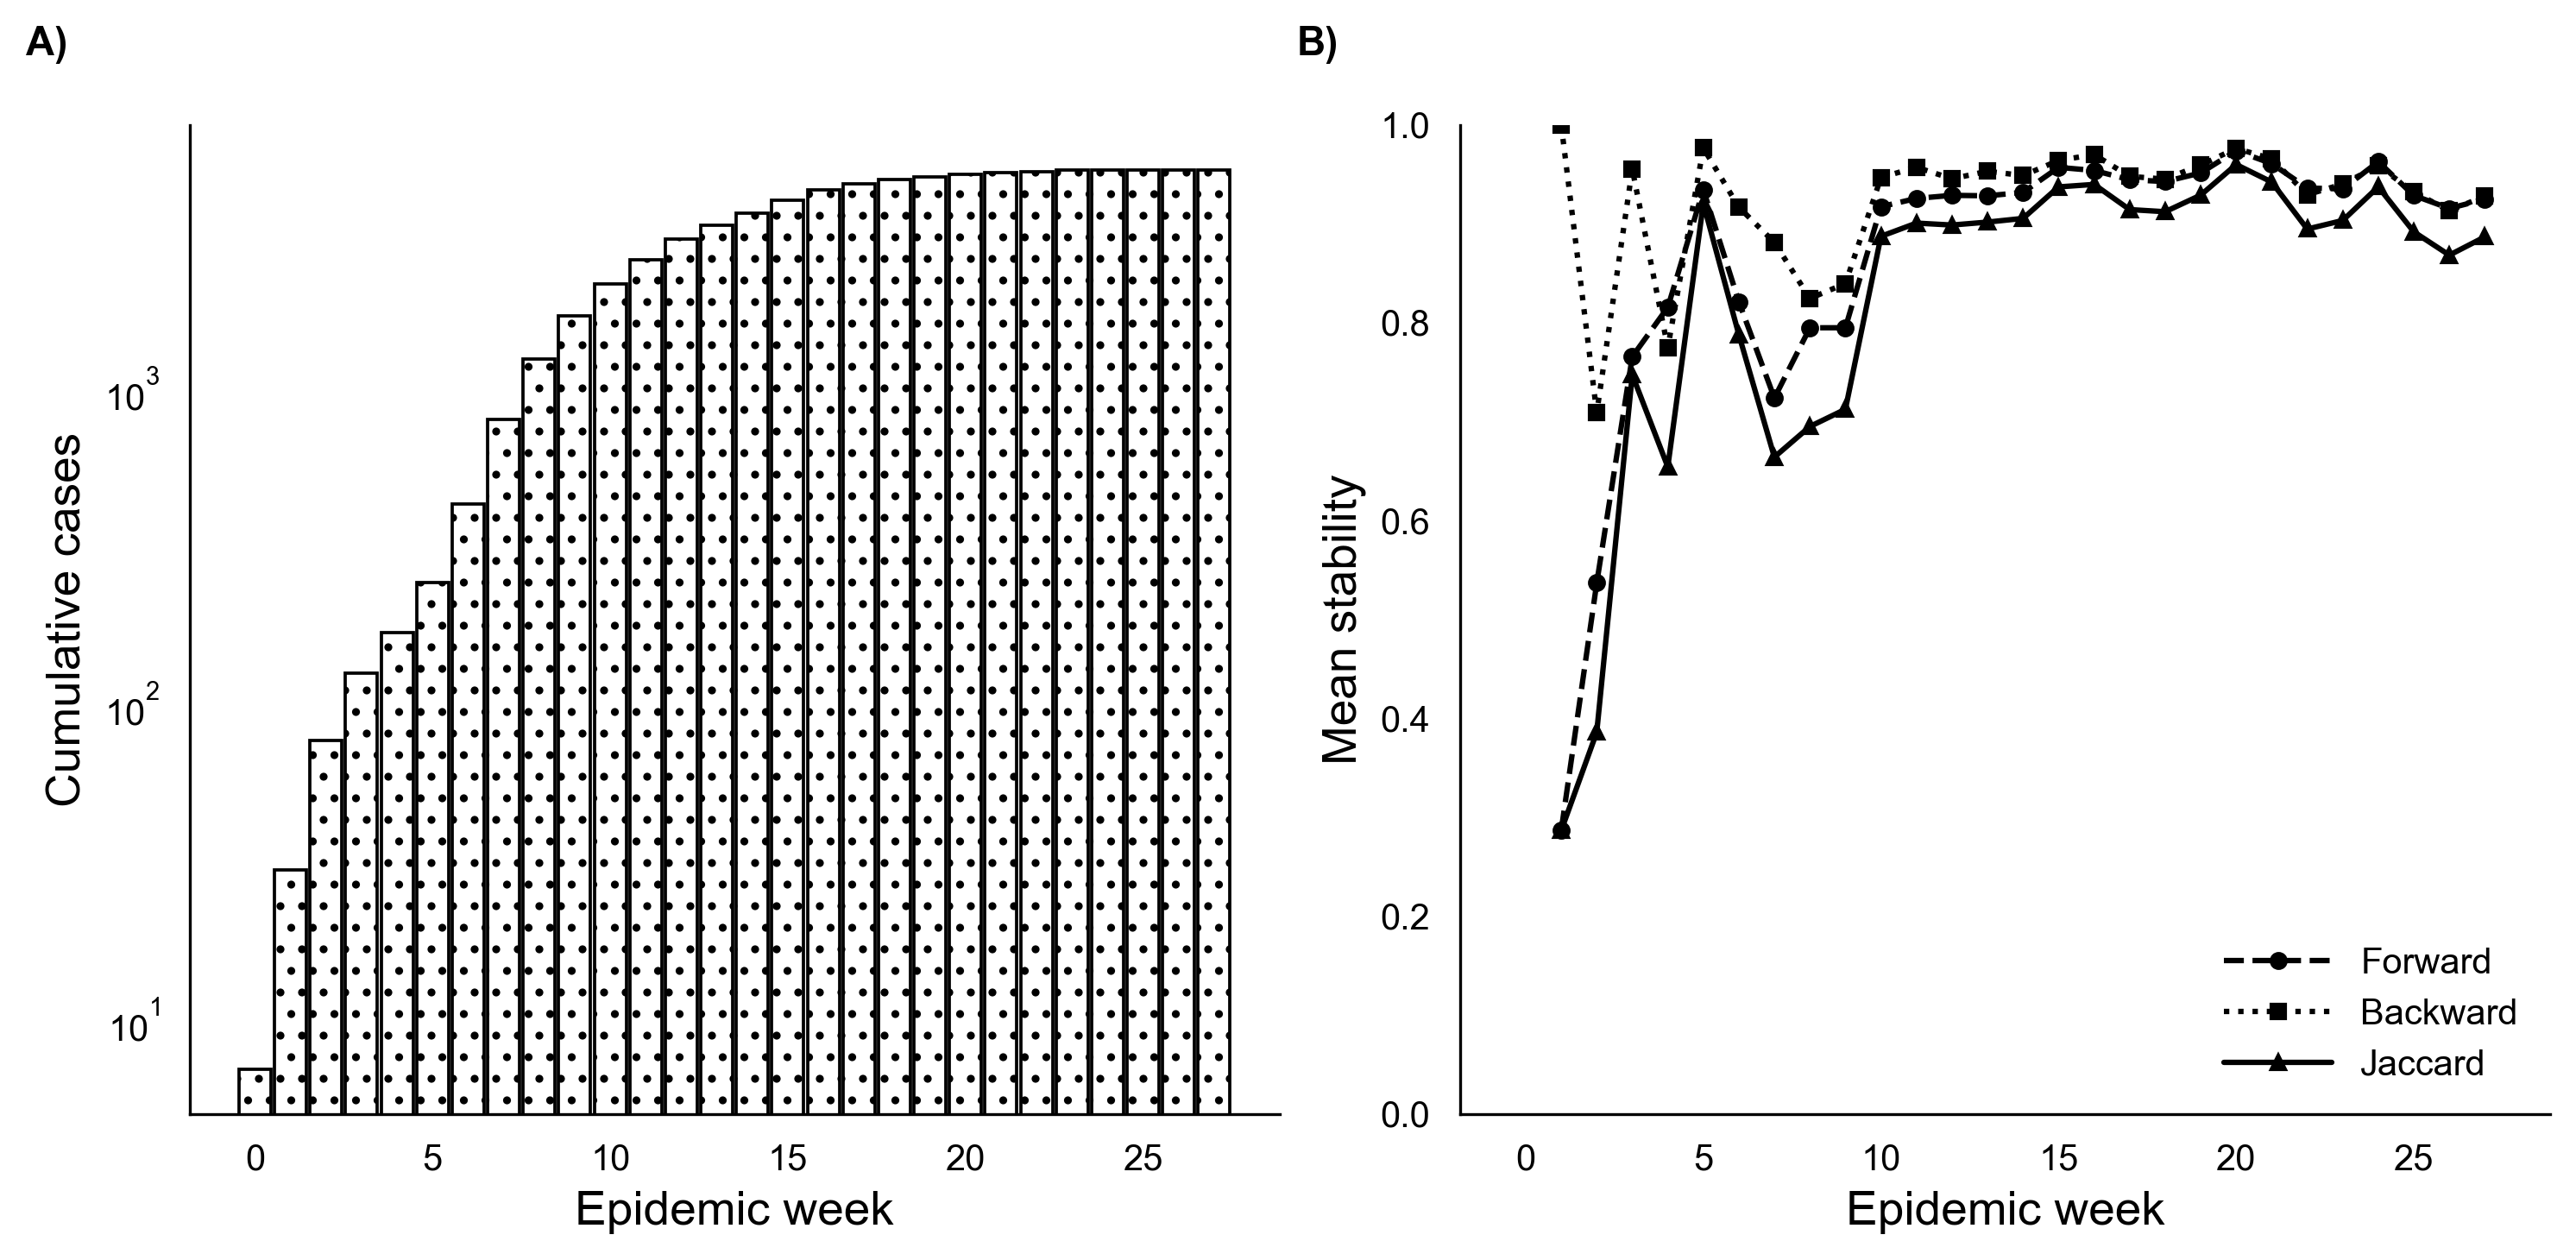

In [18]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 5), sharex=True)

ax1 = plot_cumulative_cases(data_accrual, axes[0])
ax2 = plot_stability_over_time(temporal_stability_pp, axes[1])

panel_axes = [ax1, ax2]
for ax, lab in zip(panel_axes, ["A", "B"]):
    ax.text(
        -0.15, 1.10, f"{lab})",
        transform=ax.transAxes,
        fontsize="medium", fontweight="bold",
        va="top"
    )

plt.tight_layout()
save_figure(fig, figs_dir / "temporal_stability", formats)
plt.show()
plt.close(fig)

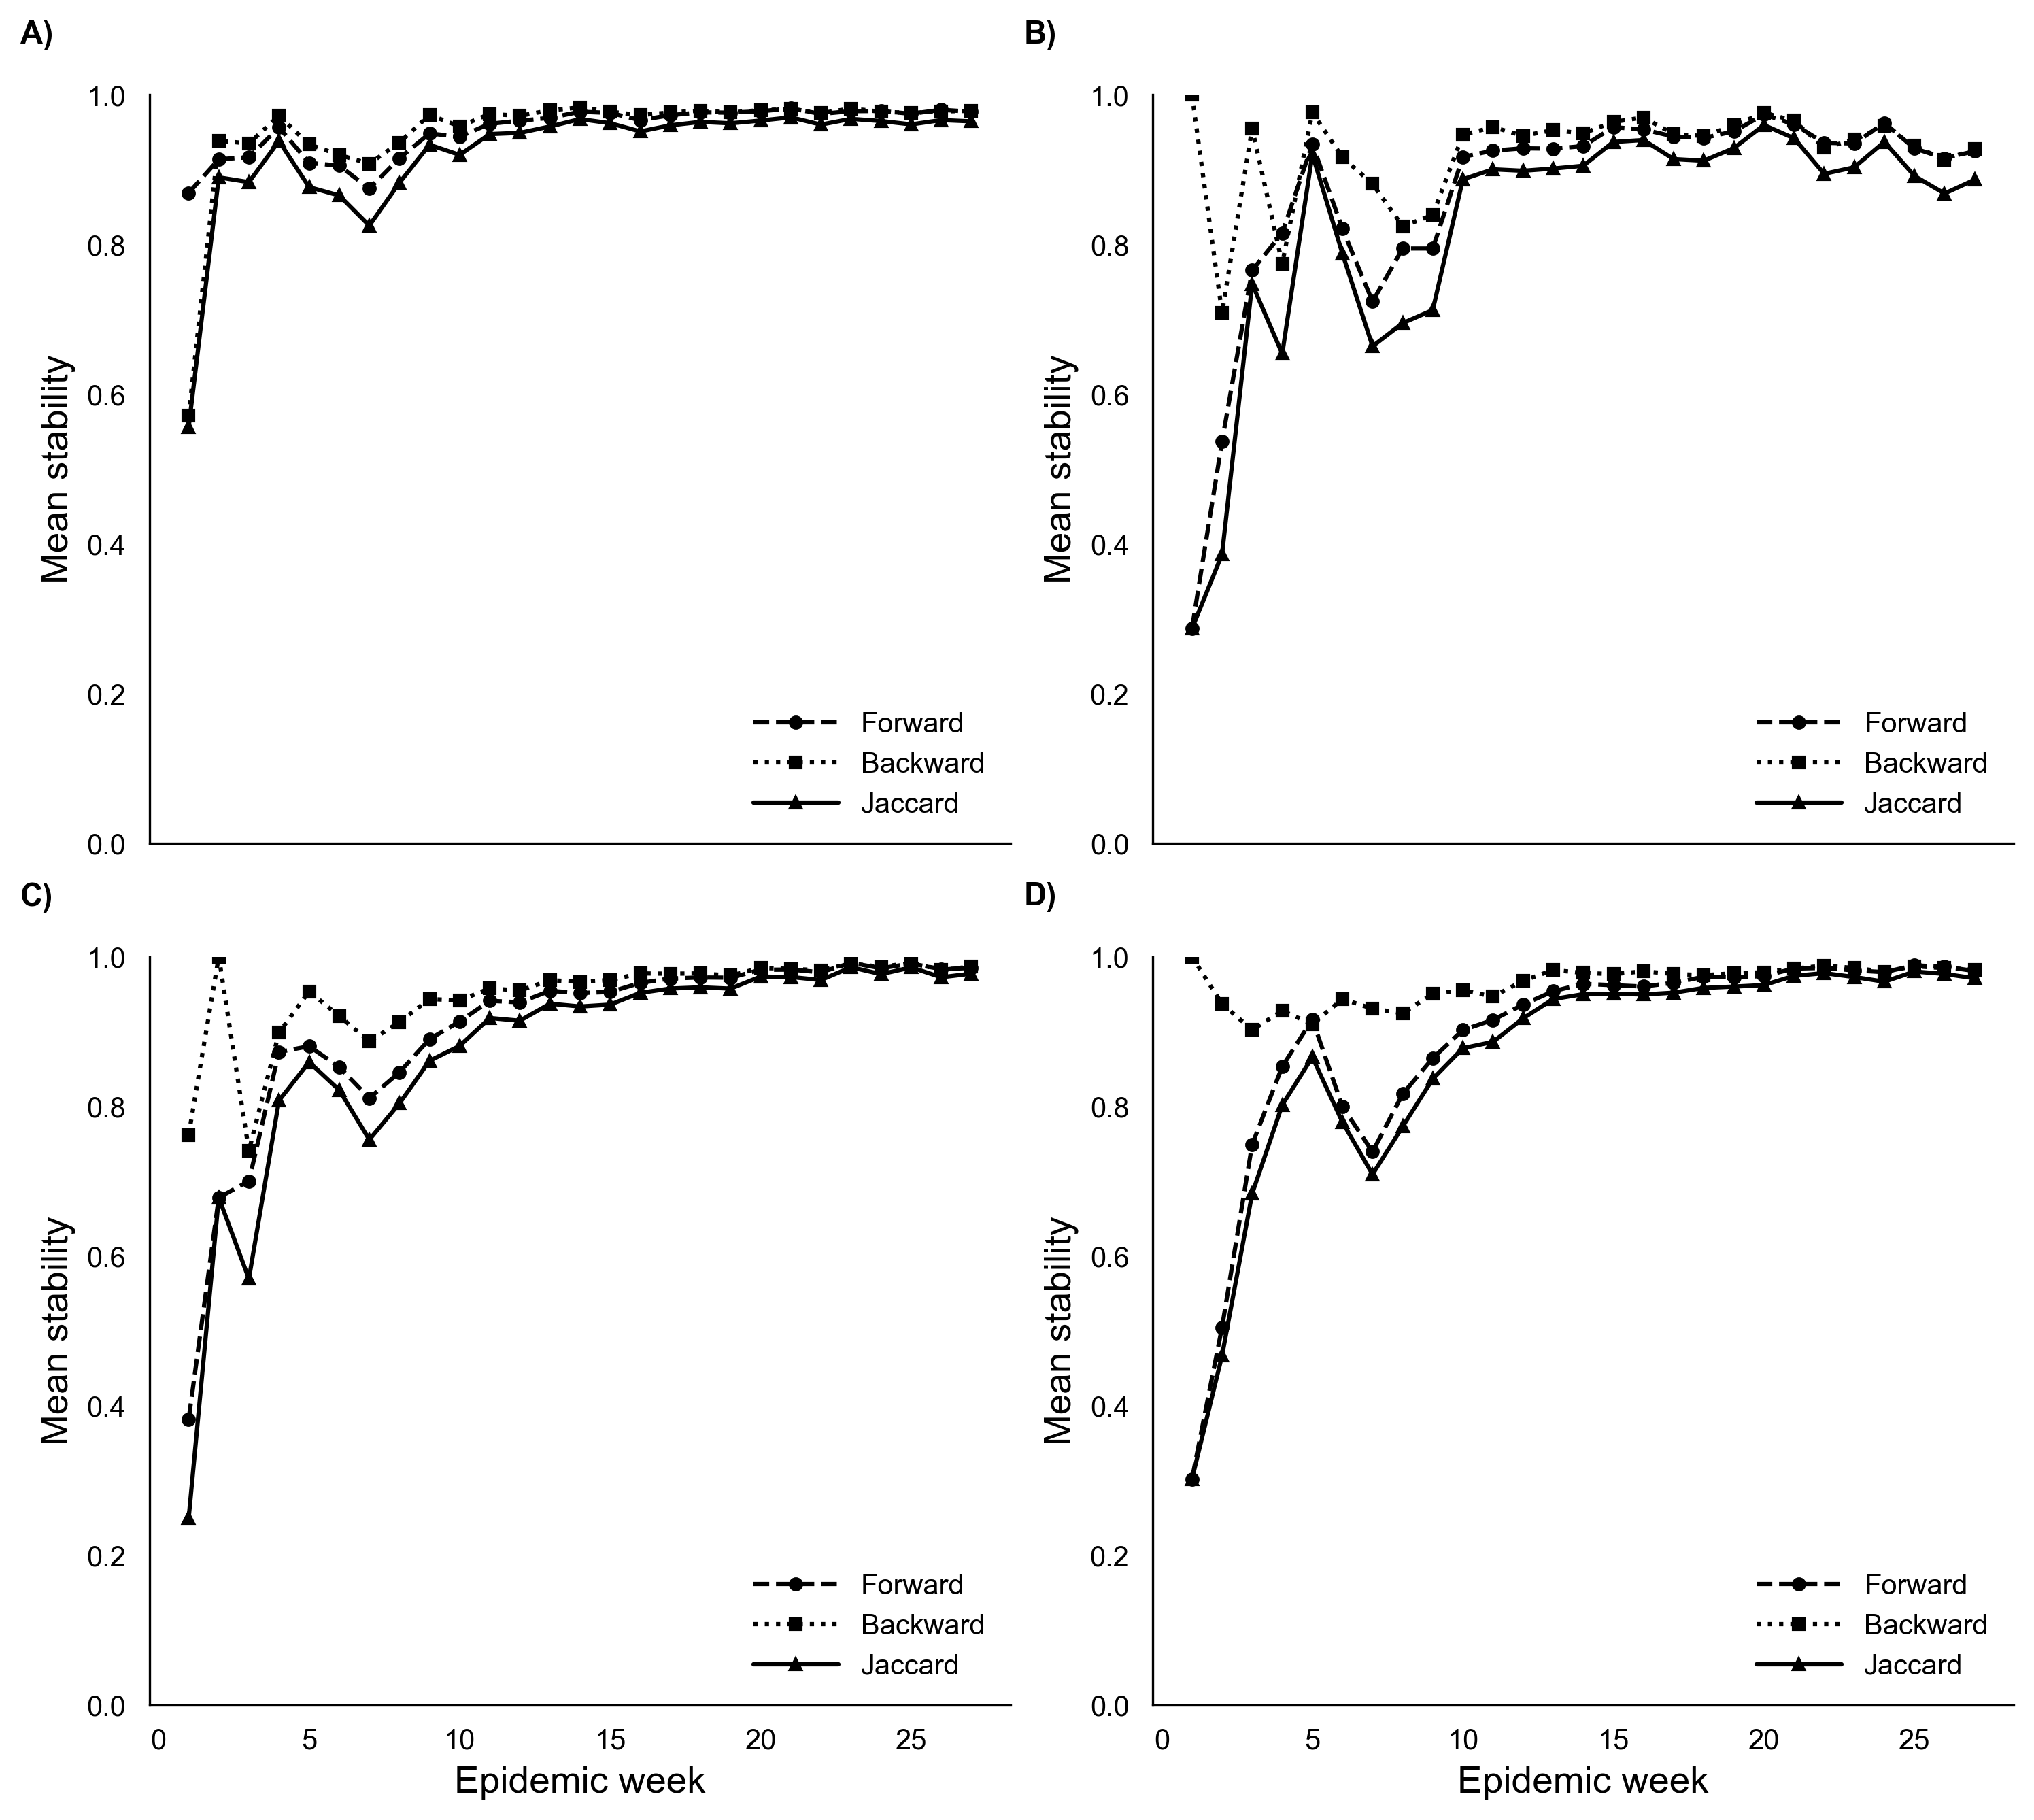

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True)

ax1 = plot_stability_over_time(temporal_stability_pl, axes[0, 0])
ax2 = plot_stability_over_time(temporal_stability_pp, axes[0, 1])
ax3 = plot_stability_over_time(temporal_stability_ll, axes[1, 0])
ax4 = plot_stability_over_time(temporal_stability_lp, axes[1, 1])

panel_axes = [ax1, ax2, ax3, ax4]
for ax, lab in zip(panel_axes, ["A", "B", "C", "D"]):
    ax.text(
        -0.15, 1.10, f"{lab})",
        transform=ax.transAxes,
        fontsize="medium", fontweight="bold",
        va="top"
    )

for ax in [ax1, ax2]:
    ax.set_xlabel("")

plt.tight_layout()
save_figure(fig, figs_dir / "sm_temporal_stability", formats)
plt.show()
plt.close(fig)

## Recovery of Boston SSE Clusters

In [20]:
boston_clusters_comp = read_table("boston/boston_cluster_composition")

exposures = [
    'count::BHCHP',
    'count::Other',
    'count::City',
    'count::Conference',
    'count::SNF'
]

exposure_counts = boston_clusters_comp[exposures].copy()
exposure_counts.rename(
    columns={
        'count::BHCHP': 'BHCHP',
        'count::Other': 'Other',
        'count::City': 'City',
        'count::Conference': 'Conference',
        'count::SNF': 'SNF'
    },
    inplace=True
)

exposure_counts.index = boston_clusters_comp['cluster_id']

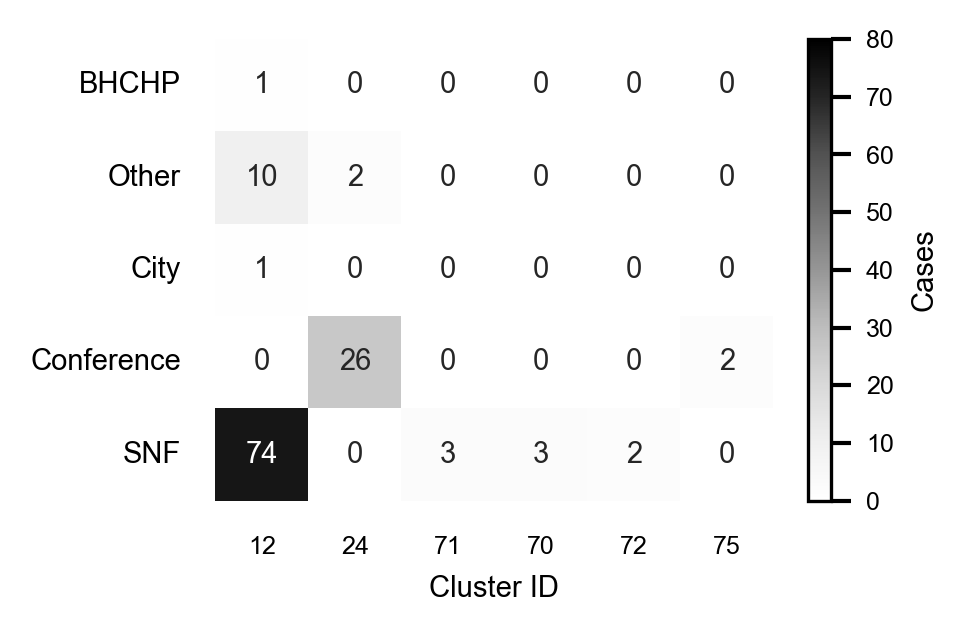

In [21]:
fig, ax = plt.subplots(figsize=(3, 2))
hm = sns.heatmap(
    exposure_counts.T,
    vmin=0, vmax=80,
    cmap="Greys",
    annot=True, fmt=".0f",
    annot_kws={"size": 7},
    cbar_kws={"label": "Cases"},
    ax=ax,
)

ax.tick_params(axis='y', labelsize=7)
ax.tick_params(axis='x', labelsize=6)
ax.set_xlabel("Cluster ID", fontsize=7)

cbar = hm.collections[0].colorbar
cbar.outline.set_edgecolor("black")
cbar.outline.set_linewidth(0.8)
cbar.ax.yaxis.label.set_size(7)
cbar.ax.tick_params(axis='y', labelsize=6)

save_figure(fig, figs_dir / "boston_cluster", formats)
plt.show()
plt.close(fig)